# Part 1: Basic I/O Scripting

## Task 1.1: Load and Display an Image

1. Write a script to load an image from disk and display it in a window.
2. Convert the image to grayscale and display the grayscale version.
3. Save the grayscale image to disk as grayscale_output.jpg

In [11]:
#libraries needed
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

image read.


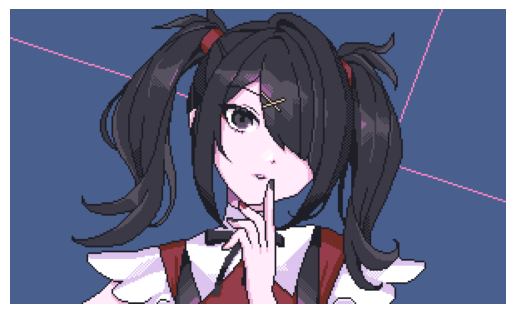

In [7]:
# Determine image path
image1_path = "Ame.png" #replace this with wherever the image is
print("image read.")
# Load image
img1 = cv2.imread(image1_path)
# Display image via matplotlib
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)#convert color config to RGB
plt.imshow(img1)
plt.axis("off")# hide axis
plt.show()

image read.


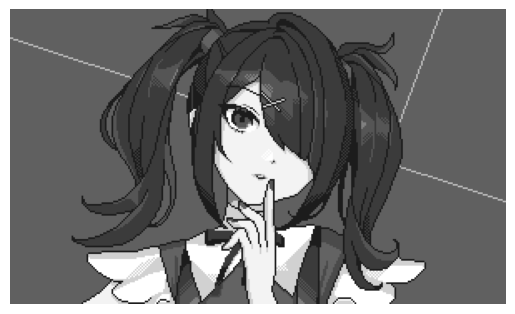

True

In [6]:
# Convert img1 to grayscale
img1_gray = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
print("image read.")
# Display grayscaled image
img1_gray = cv2.cvtColor(img1_gray, cv2.COLOR_BGR2RGB)#convert color config to RGB
plt.imshow(img1_gray)
plt.axis("off")  # hide axis
plt.show()

#saves file to current directory or folder
cv2.imwrite('grayscale_output.png', img1_gray)

## Task 1.2: Load and Play a Video

1. Write a script to load a video file.
3. Display each frame of the video in a window.
4. Implement a way to quit the video playback early by pressing the q key.
5. Save a copy of the video to disk with the filename output_video.avi

In [2]:
#libraries needed
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
# Determine video path
video_path = "nyancat.mp4" #replace this with wherever the video is

#read video file and change fps to 60fps
videoCapture = cv2.VideoCapture(video_path)
fps = videoCapture.get(cv2.CAP_PROP_FPS) or 60.0
print("file read")

#make window and print output text to verify if opening the window is successful
cv2.namedWindow('nyancat')
print('Showing camera feed. Press q to stop.')

success, frame = videoCapture.read()
while success and cv2.waitKey(1) != ord('q'): #press q to close window
  cv2.imshow('nyancat', frame) #keep reading the frames
  success, frame = videoCapture.read()

#close window
cv2.destroyWindow('nyancat')
videoCapture.release()

file read
Showing camera feed. Press q to stop.


In [11]:
#write a video output to disk
videoCapture = cv2.VideoCapture(video_path)

fps = videoCapture.get(cv2.CAP_PROP_FPS)
if fps == 0:  # fallback if FPS cannot be read
    fps = 60.0

size = (int(videoCapture.get(cv2.CAP_PROP_FRAME_WIDTH)),
        int(videoCapture.get(cv2.CAP_PROP_FRAME_HEIGHT)))

videoWriter = cv2.VideoWriter(
    'output_video.avi', 
    cv2.VideoWriter_fourcc('X','V','I','D'), 
    fps, size)

success, frame = videoCapture.read()
while success:  # Loop until there are no more frames
    videoWriter.write(frame)
    success, frame = videoCapture.read()

videoCapture.release()
videoWriter.release()


# Part 2: Edge and Contour Detection

## Task 2.1: Edge Detection on an Image

In [15]:
#libraries needed
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [13]:
img = cv2.imread(image1_path, 0)

#write output in same directory
cv2.imwrite("edges_output.jpg", cv2.Canny(img, 200, 300))

True

showing edge-detected image


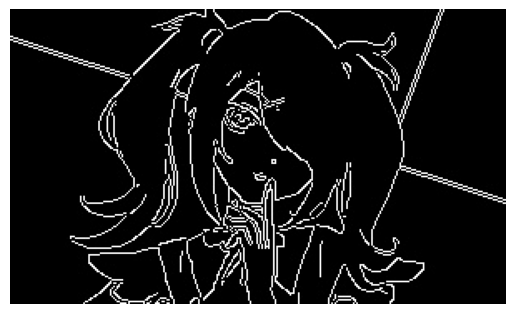

In [17]:
canny = cv2.imread('edges_output.jpg')
print('showing edge-detected image')
#display output
canny = cv2.cvtColor(canny, cv2.COLOR_BGR2RGB)#convert color config to RGB
plt.imshow(canny)
plt.axis("off")  # hide axis
plt.show()

## Task 2.2: Contour Detection and Drawing

1.	Using the edge-detected image from Task 2.1, find contours.
2.	Draw all contours on the original image in green color with a thickness of 2.
3.	Display the image with contours.


In [28]:
img = cv2.imread('edges_output.jpg')

ret, thresh = cv2.threshold(cv2.cvtColor(img.copy(), cv2.COLOR_BGR2GRAY), 127, 255, cv2.THRESH_BINARY)
contours, hier = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for c in contours:
  # Find the bounding box coordinates
  x, y, w, h = cv2.boundingRect(c)
  cv2.rectangle(img, (x,y), (x+w, y+h), (0, 255, 0), 2)

  # Find minimum area
  rect = cv2.minAreaRect(c)

  # Calculate coordinates of the minimum area rectangle
  box = cv2.boxPoints(rect)

  # Normalize coordinates to integers
  box = np.int0(box)

  # Draw contours
  cv2.drawContours(img, [box], 0, (0, 255, 0), 3)

  # Calculate center and radius of minimu enclosing circle
  (x, y), radius = cv2.minEnclosingCircle(c)

  # Cast to integers
  center = (int(x), int(y))
  radius = int(radius)

  # Draw the circle
  img = cv2.circle(img, center, radius, (0, 255, 0), 2)

cv2.drawContours(img, contours, -1, (0, 255, 0), 1)
#write image file with contours
contours_output = cv2.imwrite("contours_output.jpg", img)

#display output
cv2.imshow("Contour", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

C:\Users\Leon Pascual\AppData\Local\Temp\ipykernel_9496\1372851163.py:17: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)
